In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

from model.loss_function.siamese.custom_siamese_loss import CustomSiameseLoss
from model.architecture.basic_siamese import BasicSiameseModel
from model.architecture.advanced_siamese import AdvancedSiameseModel
from data_augmentation.matrices_loader import MatricesLoader
from model.architecture.dense import DeepAHPNet
from model.loss_function.dense.custom_dense_loss import CustomDenseLoss
from model.trainers.siamese_trainer import SiameseTrainer
from model.trainers.dense_trainer import DenseTrainer
from utils.io_utils import *
from analytic_methods.EVM_method import EVM
from visualization.results.metrics_visualizator import MetricsVisualizator
from visualization.data.weights_visualizator import WeightsVisualizator
from metrics.evaluator import Evaluator
from model.trainers.graph_trainer import GraphTrainer
from model.loss_function.graph.custom_graph_loss import CustomGraphLoss
from model.architecture.graph import GraphAHPNet

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cpu


/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/venv_gpu/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4]
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

BATCH_SIZE = 32
LEARNING_RATE = 0.001

In [4]:
def compare_results_batch(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrices, weights_vectors, pred_weights_vectors in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        mae_nn, kendal_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)

        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))
        all_mae_nn.append(np.mean(mae_nn))
        all_kendall_taus_nn.append(np.mean(kendal_taus_nn))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)

## Siamese Neural Network

In [ ]:
loader = MatricesLoader()
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr001).
Successfully uploaded 10000 noised matrices (level: cr002).
Successfully uploaded 10000 noised matrices (level: cr003).
Successfully uploaded 10000 noised matrices (level: cr004).


KeyboardInterrupt: 

In [ ]:
COP = 2
REC = 3
STAB = 0.1
CONS = 0.5
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

## Dense Neural Network 

In [5]:
loader = MatricesLoader()
train_dataset = load_train_dataset_dnn(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_dnn(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr001).
Successfully uploaded 10000 noised matrices (level: cr002).
Successfully uploaded 10000 noised matrices (level: cr003).
Successfully uploaded 10000 noised matrices (level: cr004).
Successfully uploaded 10000 noised matrices (level: cr005).
Successfully uploaded 10000 noised matrices (level: cr007).
Successfully uploaded 10000 noised matrices (level: cr008).
Successfully uploaded 10000 noised matrices (level: cr010).
Successfully uploaded 10000 noised matrices (level: cr012).
Successfully uploaded 10000 noised matrices (level: cr014).
Successfully uploaded 10000 noised matrices (level: cr015).
Successfully uploaded 10000 noised matrices (level: cr017).
Successfully uploaded 10000 noised matrices (level: cr018).
Successfully uploaded 10000 noised matrices (level: cr020).
Successfully uploaded 10000 noised matrices (level: cr023).
Successfully uploaded 10000 noised matrices (level: cr027).
Successfully uploaded 10000 noised matri

In [ ]:
COP = 4
REC = 3
STAB = 0.5
MODEL_TYPE = "dense"
MODEL_NAME = f"basic_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = DeepAHPNet(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomDenseLoss(n_criteria=CRITERIA_NUM, lambda_cop=COP, lambda_rec=REC, lambda_stab=STAB).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = DenseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.776335 | Valid Loss: 0.623199 | Valid MAE: 0.0495
Epoch number [20/500] | Train Loss: 0.773437 | Valid Loss: 0.618594 | Valid MAE: 0.0491
Epoch number [30/500] | Train Loss: 0.772117 | Valid Loss: 0.620884 | Valid MAE: 0.0499
Epoch number [40/500] | Train Loss: 0.770473 | Valid Loss: 0.613515 | Valid MAE: 0.0503
Epoch number [50/500] | Train Loss: 0.770645 | Valid Loss: 0.618061 | Valid MAE: 0.0494
Epoch number [60/500] | Train Loss: 0.771299 | Valid Loss: 0.621468 | Valid MAE: 0.0493
Epoch number [70/500] | Train Loss: 0.771335 | Valid Loss: 0.612859 | Valid MAE: 0.0496

EARLY STOPPING in epoch 73.
Wages are restored to the best valid loss: 0.611234
History and model: basic_10000m_5crit was saved in models/dense/cop400_rec300_stab10


In [7]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr001).
Successfully uploaded 1000 noised matrices (level: cr002).
Successfully uploaded 1000 noised matrices (level: cr003).
Successfully uploaded 1000 noised matrices (level: cr004).
Successfully uploaded 1000 noised matrices (level: cr005).
Successfully uploaded 1000 noised matrices (level: cr007).
Successfully uploaded 1000 noised matrices (level: cr008).
Successfully uploaded 1000 noised matrices (level: cr010).
Successfully uploaded 1000 noised matrices (level: cr012).
Successfully uploaded 1000 noised matrices (level: cr014).
Successfully uploaded 1000 noised matrices (level: cr015).
Successfully uploaded 1000 noised matrices (level: cr017).
Successfully uploaded 1000 noised matrices (level: cr018).
Successfully uploaded 1000 noised matrices (level: cr020).
Successfully uploaded 1000 noised matrices (level: cr023).
Successfully uploaded 1000 noised matrices (level: cr027).
Successfully uploaded 1000 noised matrices (level: cr030

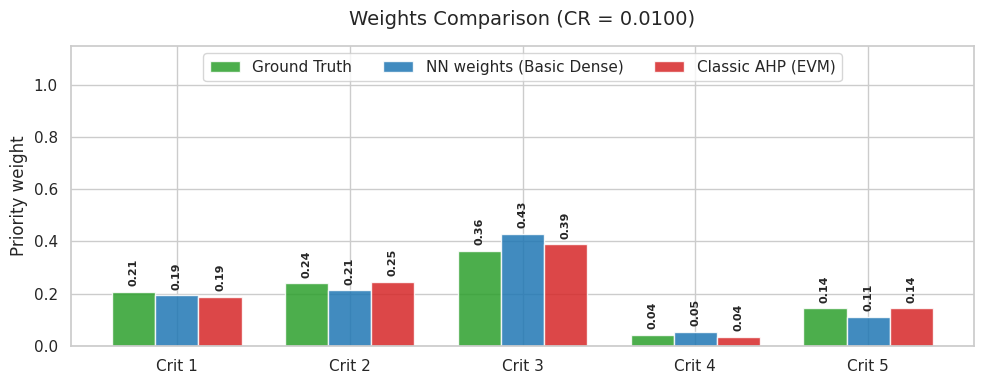

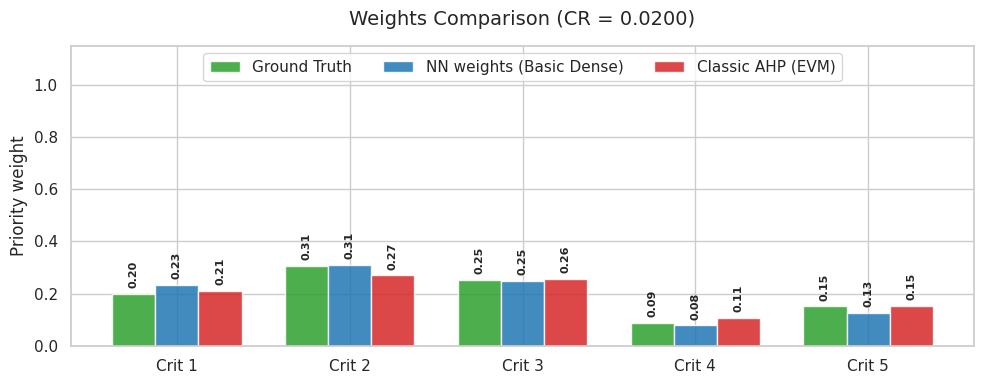

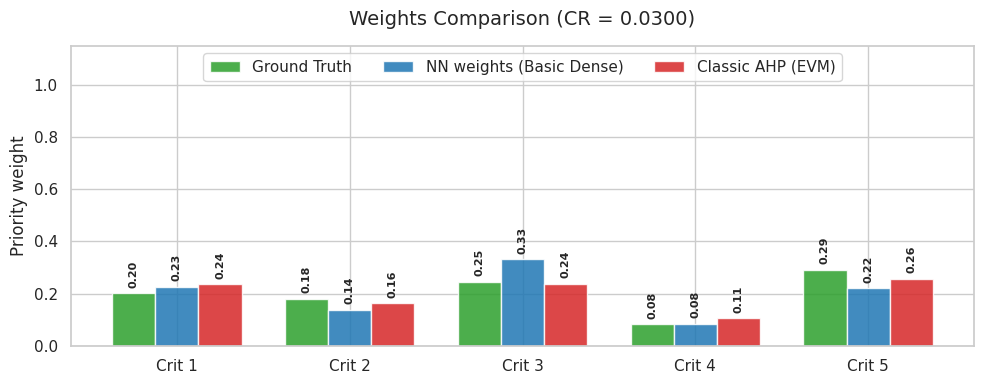

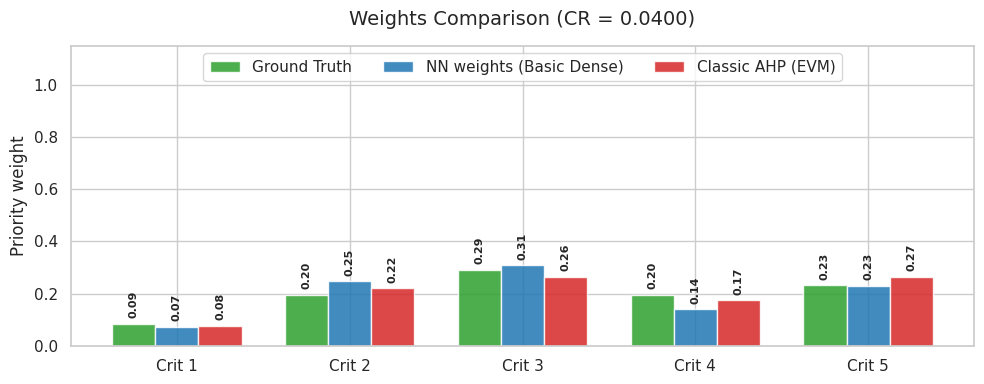

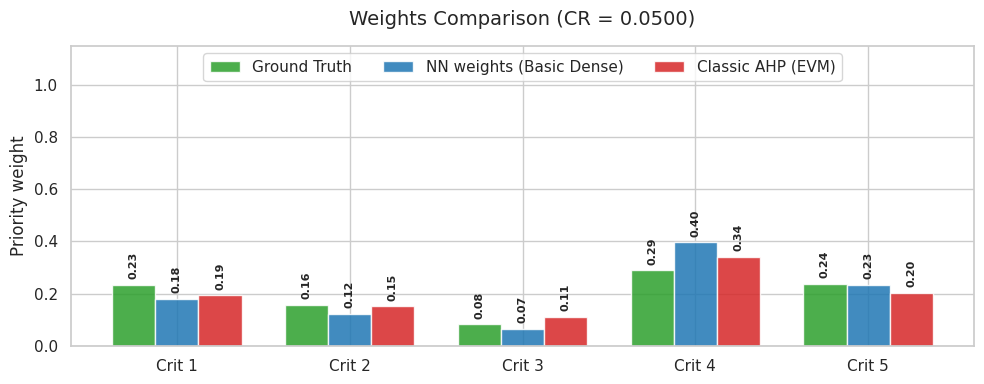

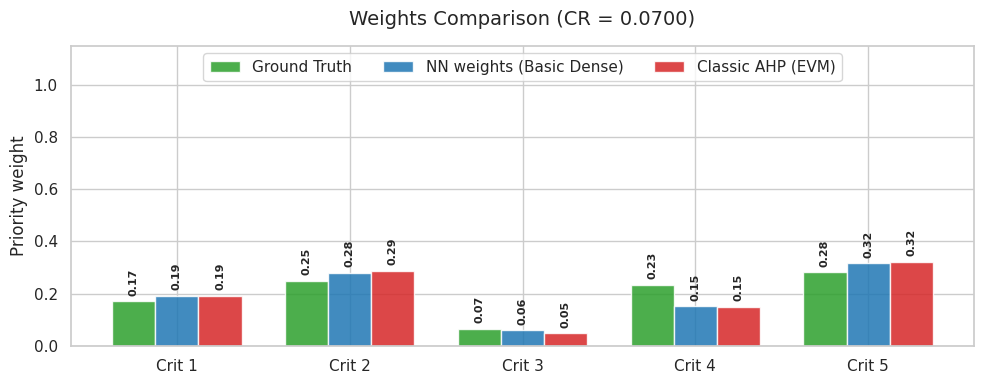

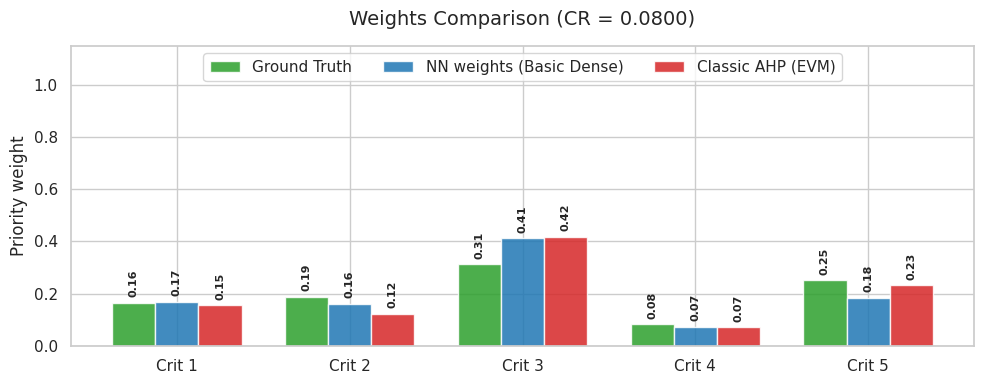

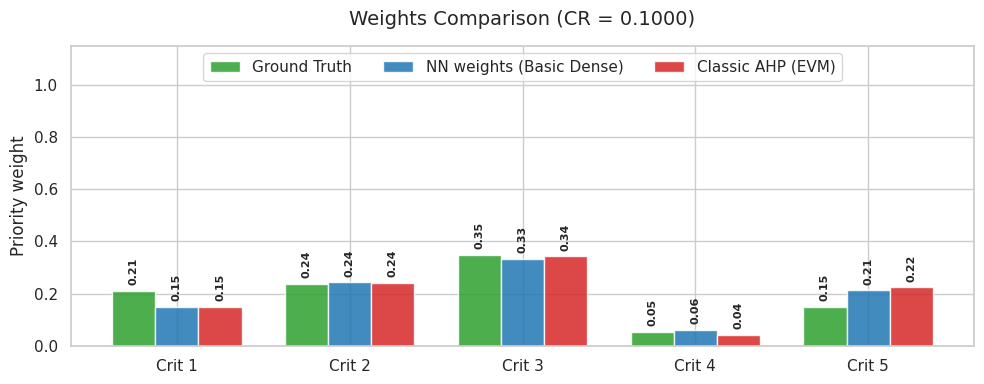

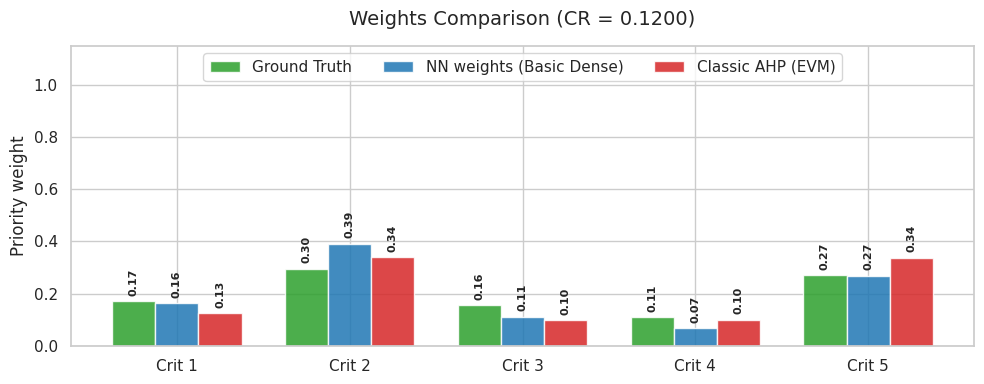

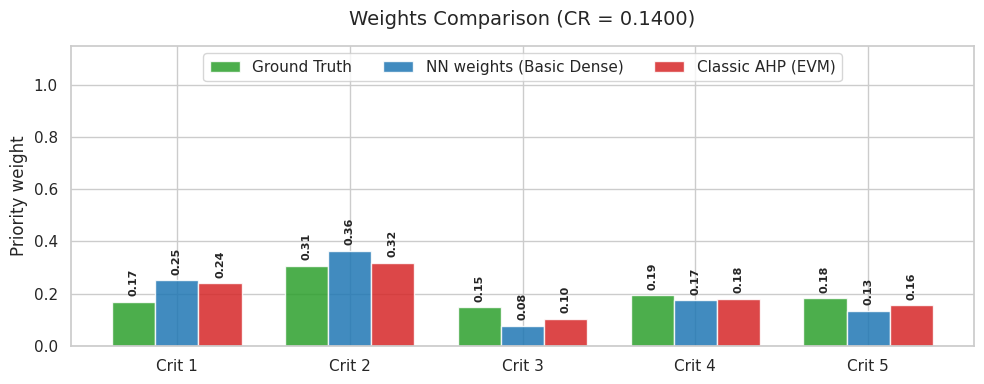

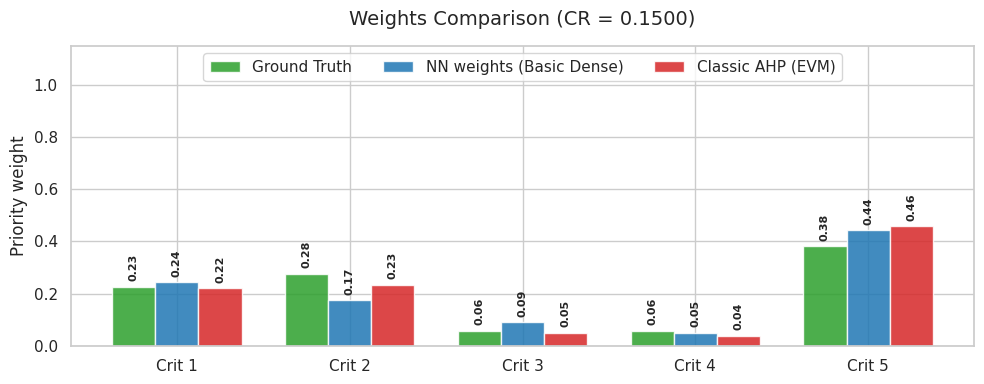

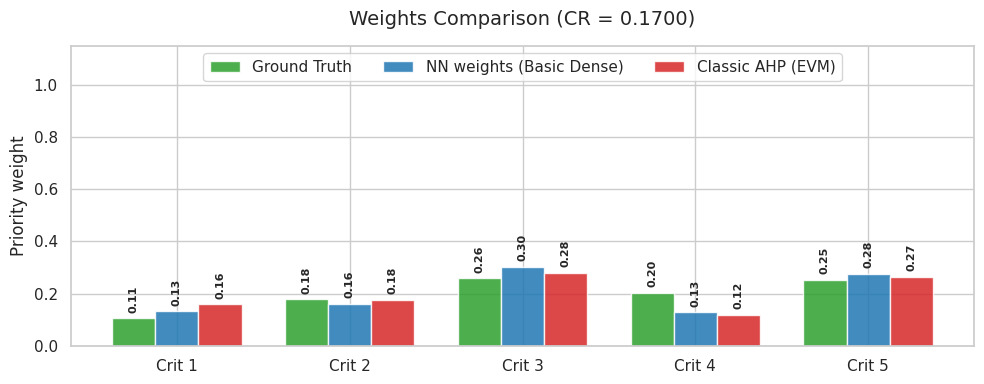

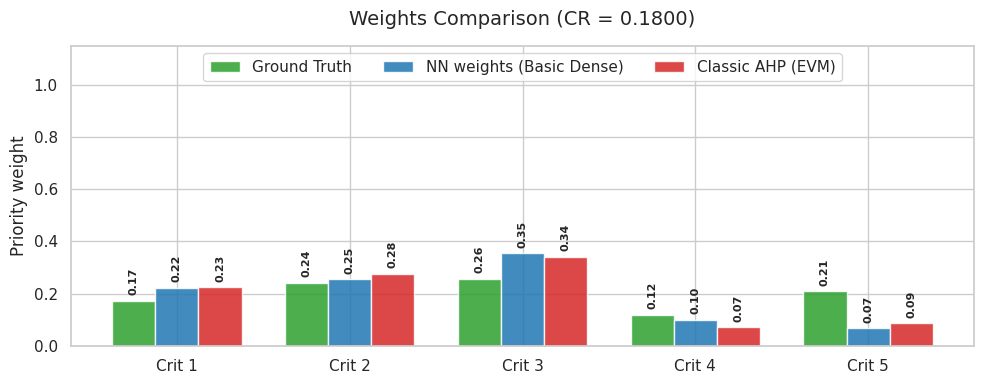

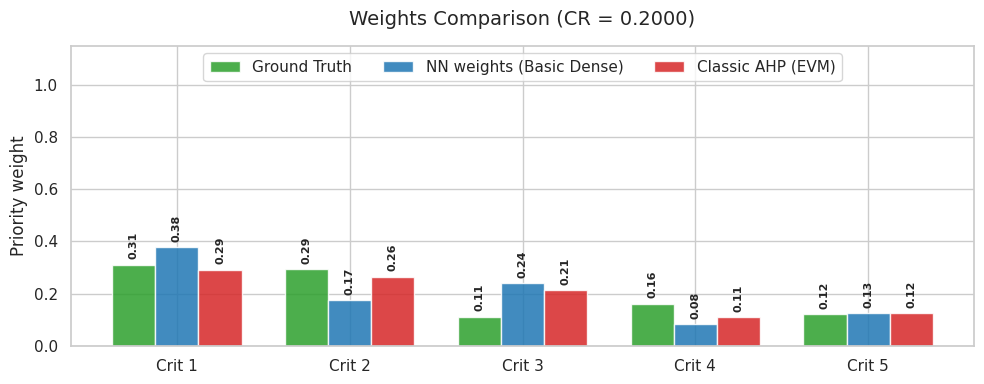

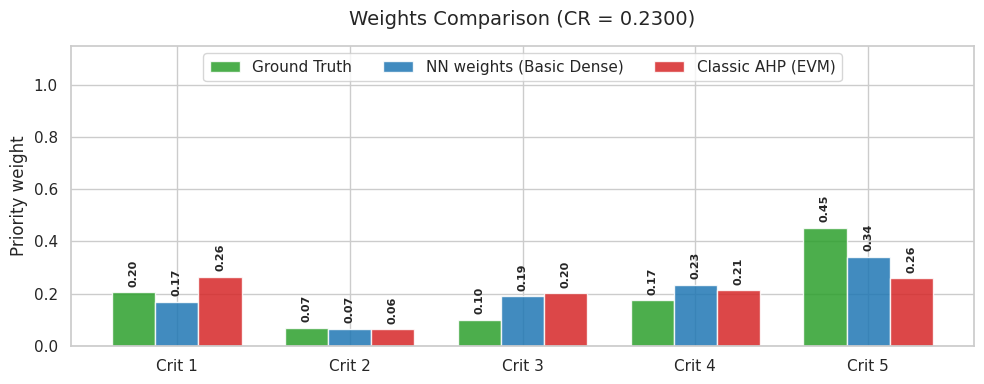

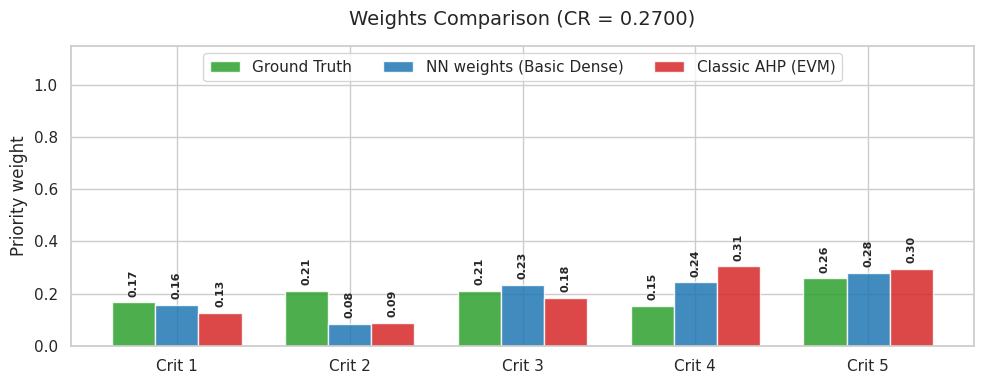

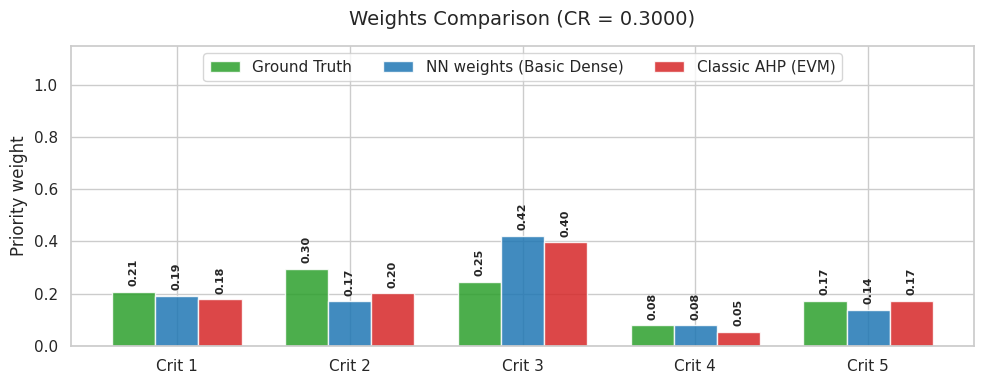

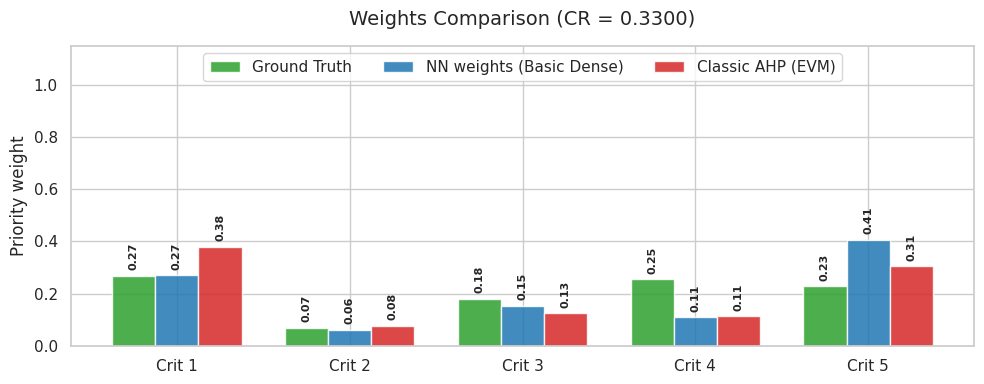

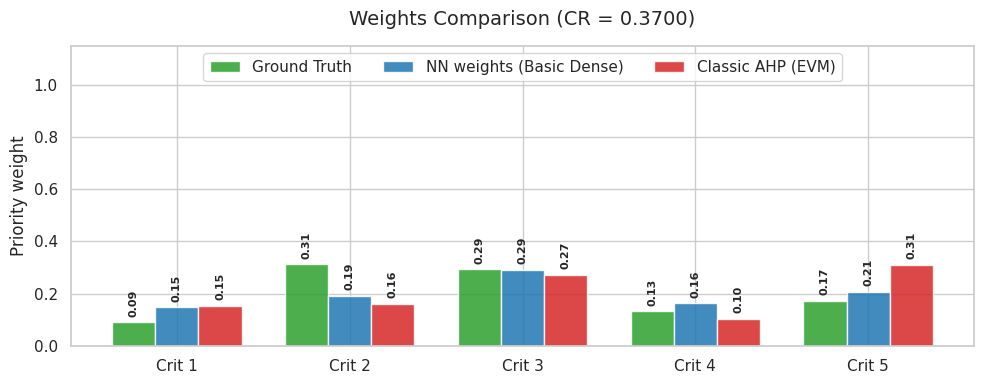

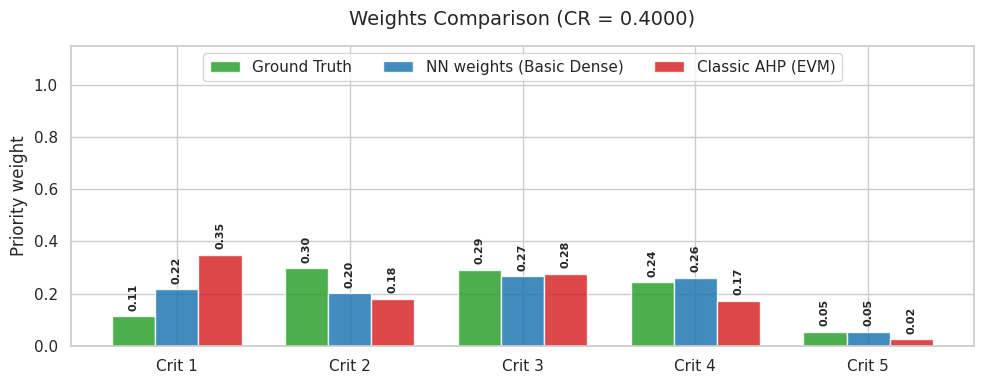

In [8]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 20 consistency rates.
Global mean CR: 0.1630
Global mean MAE (EVM): 0.0499, NN: 0.0502
Global mean Kendall correlation (EVM): 0.6368, NN: 0.6152


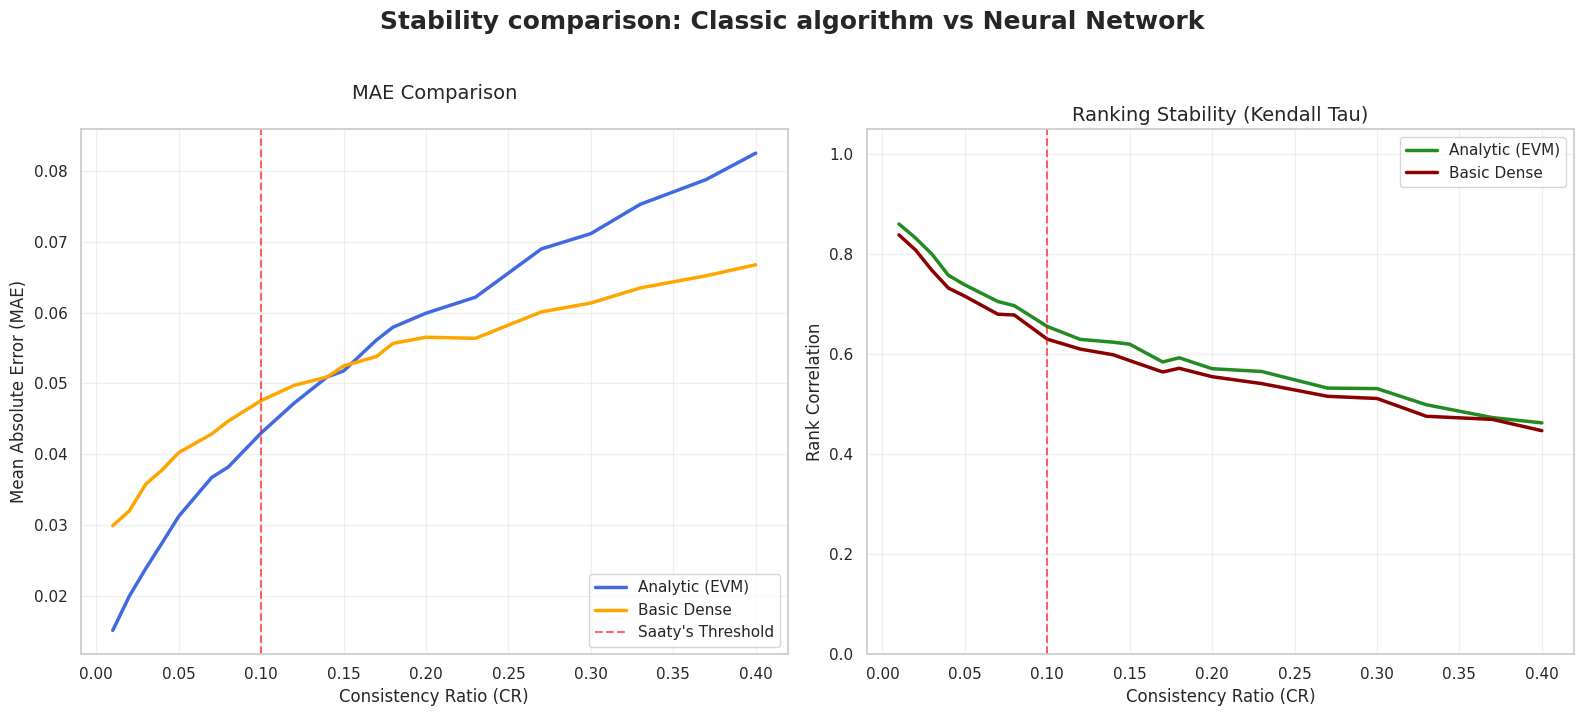

In [9]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

## Graph Neural Network

In [ ]:
loader = MatricesLoader()
train_dataset = load_train_dataset_graph(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_graph(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

In [ ]:
COP = 4
REC = 3
STAB = 0.1
MODEL_TYPE = "graph"
MODEL_NAME = f"basic_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = GraphAHPNet(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomGraphLoss(n_criteria=CRITERIA_NUM, lambda_cop=COP, lambda_rec=REC, lambda_stab=STAB).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = GraphTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

In [ ]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

In [ ]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)

In [ ]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)